In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import torch
import numpy as np

In [46]:
from gnnboundary import *
from gnnboundary.datasets.reddit_multi_5k_dataset import *

# REDDIT-MULTI-5K


In [47]:
# dataset = CollabDataset(seed=12345)
dataset = RedditMultiDataset(seed=12345)

In [58]:
model = GCNClassifier(
    node_features=len(dataset.NODE_CLS),
    num_classes=len(dataset.GRAPH_CLS),
    hidden_channels=64,
    num_layers=5,
)
model.load_state_dict(torch.load("ckpts/collab.pt"))

<All keys matched successfully>

In [59]:
dataset_list_gt = dataset.split_by_class()
dataset_list_pred = dataset.split_by_pred(model)
print(len(dataset_list_gt[0]))

/Users/Caspar/opt/anaconda3/envs/gnnboundary/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)
/Users/Caspar/opt/anaconda3/envs/gnnboundary/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal

500


In [60]:
evaluation = dataset.model_evaluate(model)
evaluation

{'acc': 0.3499999940395355,
 'cm': array([[ 25,  91, 384],
        [ 16,  56, 428],
        [  8,  48, 444]]),
 'f1': {'Comedy': 0.09107468277215958,
  'Romance': 0.16115108132362366,
  'Sci-Fi': 0.5056947469711304}}

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

properties = dataset.analyze_graph_properties()

# Convert to pandas DataFrames for analysis
dfs = {}
for genre, props in properties.items():
    dfs[genre] = pd.DataFrame(props)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle("Graph Properties by Genre")

# Box plots for each metric
metrics = ["nodes", "edges", "density", "avg_degree"]
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    data = []
    labels = []
    for genre in ["Comedy", "Romance", "Sci-Fi"]:
        data.extend(dfs[genre][metric])
        labels.extend([genre] * len(dfs[genre]))

    sns.boxplot(x=labels, y=data, ax=ax)
    ax.set_title(f'{metric.replace("_", " ").title()} Distribution')
    ax.set_xlabel("Genre")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics by Genre:")
for genre in ["Comedy", "Romance", "Sci-Fi"]:
    print(f"\n{genre} graphs:")
    print(dfs[genre].describe())

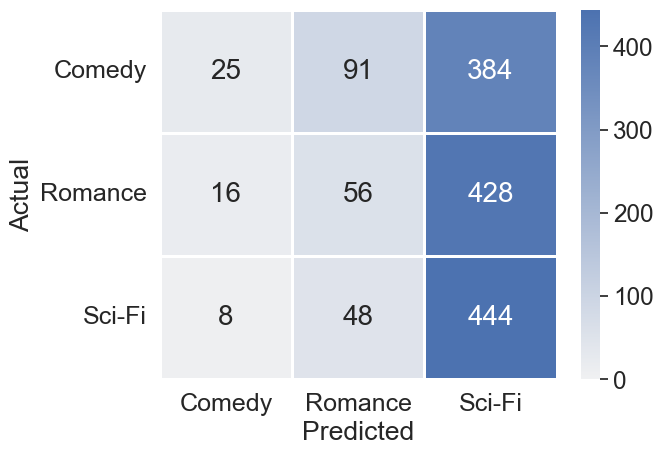

In [61]:
draw_matrix(evaluation["cm"], dataset.GRAPH_CLS.values(), fmt="d")

In [32]:
mean_embeds = [
    d.model_transform(model, key="embeds").mean(dim=0) for d in dataset_list_gt
]

/Users/Caspar/opt/anaconda3/envs/gnnboundary/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


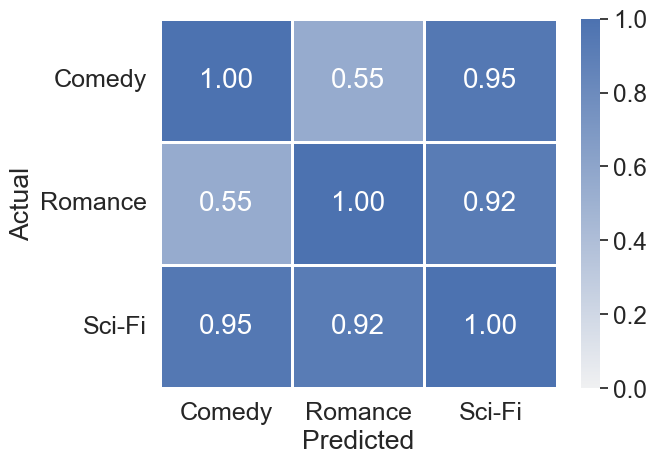

In [33]:
adj_ratio_mat, boundary_info = pairwise_boundary_analysis(model, dataset_list_pred)
draw_matrix(adj_ratio_mat, names=dataset.GRAPH_CLS.values(), fmt=".2f")

In [66]:
trainer = {}
sampler = {}

# 0 & 1


In [67]:
cls_1, cls_2 = 0, 1
trainer[cls_1, cls_2] = Trainer(
    sampler=(
        s := GraphSampler(
            max_nodes=25,
            temperature=0.2,
            num_node_cls=len(dataset.NODE_CLS),
            learn_node_feat=True,
        )
    ),
    discriminator=model,
    criterion=WeightedCriterion(
        [
            dict(
                key="logits",
                criterion=DynamicBalancingBoundaryCriterion(classes=[cls_1, cls_2]),
                weight=25,
            ),
            dict(
                key="embeds",
                criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_1]),
                weight=0,
            ),
            dict(
                key="embeds",
                criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_2]),
                weight=0,
            ),
            dict(key="logits", criterion=MeanPenalty(), weight=0),
            dict(key="omega", criterion=NormPenalty(order=1), weight=2),
            dict(key="omega", criterion=NormPenalty(order=2), weight=1),
            # dict(key="xi", criterion=NormPenalty(order=1), weight=0),
            # dict(key="xi", criterion=NormPenalty(order=2), weight=0),
            # dict(key="eta", criterion=NormPenalty(order=1), weight=0),
            # dict(key="eta", criterion=NormPenalty(order=2), weight=0),
            dict(
                key="theta_pairs", criterion=KLDivergencePenalty(binary=True), weight=0
            ),
        ]
    ),
    optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    dataset=dataset,
    budget_penalty=BudgetPenalty(budget=10, order=2, beta=1),
)

In [68]:
cls_1, cls_2 = 0, 1
trainer[cls_1, cls_2].train(
    iterations=2000,
    target_probs={cls_1: (0.4, 0.6), cls_2: (0.4, 0.6)},
    target_size=30,
    w_budget_init=1,
    w_budget_inc=1.1,
    w_budget_dec=0.95,
    k_samples=16,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

True

n=23 m=25
logits=[0.6380758881568909, 1.1754276752471924, -1.3799282312393188]
probs=[0.3515693247318268, 0.6016998291015625, 0.04673076421022415]


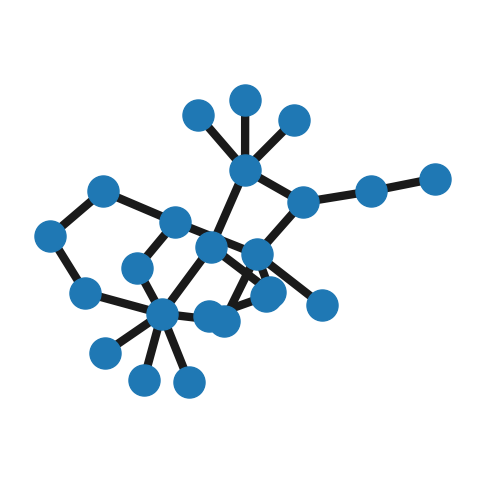

In [70]:
trainer[0, 1].evaluate(threshold=0.5, show=True)

# 0 & 2


In [71]:
cls_1, cls_2 = 0, 2
trainer[cls_1, cls_2] = Trainer(
    sampler=(
        s := GraphSampler(
            max_nodes=25,
            temperature=0.2,
            num_node_cls=len(dataset.NODE_CLS),
            learn_node_feat=True,
        )
    ),
    discriminator=model,
    criterion=WeightedCriterion(
        [
            dict(
                key="logits",
                criterion=DynamicBalancingBoundaryCriterion(classes=[cls_1, cls_2]),
                weight=25,
            ),
            dict(
                key="embeds",
                criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_1]),
                weight=0,
            ),
            dict(
                key="embeds",
                criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_2]),
                weight=0,
            ),
            dict(key="logits", criterion=MeanPenalty(), weight=0),
            dict(key="omega", criterion=NormPenalty(order=1), weight=2),
            dict(key="omega", criterion=NormPenalty(order=2), weight=1),
            # dict(key="xi", criterion=NormPenalty(order=1), weight=0),
            # dict(key="xi", criterion=NormPenalty(order=2), weight=0),
            # dict(key="eta", criterion=NormPenalty(order=1), weight=0),
            # dict(key="eta", criterion=NormPenalty(order=2), weight=0),
            dict(
                key="theta_pairs", criterion=KLDivergencePenalty(binary=True), weight=0
            ),
        ]
    ),
    optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    dataset=dataset,
    budget_penalty=BudgetPenalty(budget=10, order=2, beta=1),
)

In [72]:
cls_1, cls_2 = 0, 2
trainer[cls_1, cls_2].train(
    iterations=2000,
    target_probs={cls_1: (0.4, 0.6), cls_2: (0.4, 0.6)},
    target_size=30,
    w_budget_init=1,
    w_budget_inc=1.1,
    w_budget_dec=0.95,
    k_samples=16,
)

  0%|          | 0/2000 [00:00<?, ?it/s]

True

n=22 m=22
logits=[0.43437251448631287, -3.9777917861938477, -0.569744884967804]
probs=[0.7254278659820557, 0.00879864301532507, 0.2657734453678131]


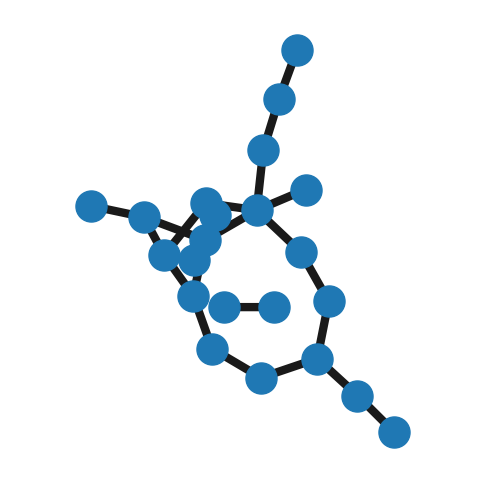

In [73]:
trainer[0, 2].evaluate(threshold=0.5, show=True)